In [ ]:
import psycopg2
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [18]:

load_dotenv(dotenv_path="../preparation/.env")
user = os.getenv('DB_user')
password = os.getenv('DB_password')
host = os.getenv('DB_host')
port = os.getenv('DB_port')
db = os.getenv('DB_name')


engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}/{db}")


/var/folders/_v/_9mt54_56fg9grgdrq21pqgc0000gn/T/ipykernel_90289/1385512054.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['sales_month'] = pd.to_datetime(df['sales_month'])


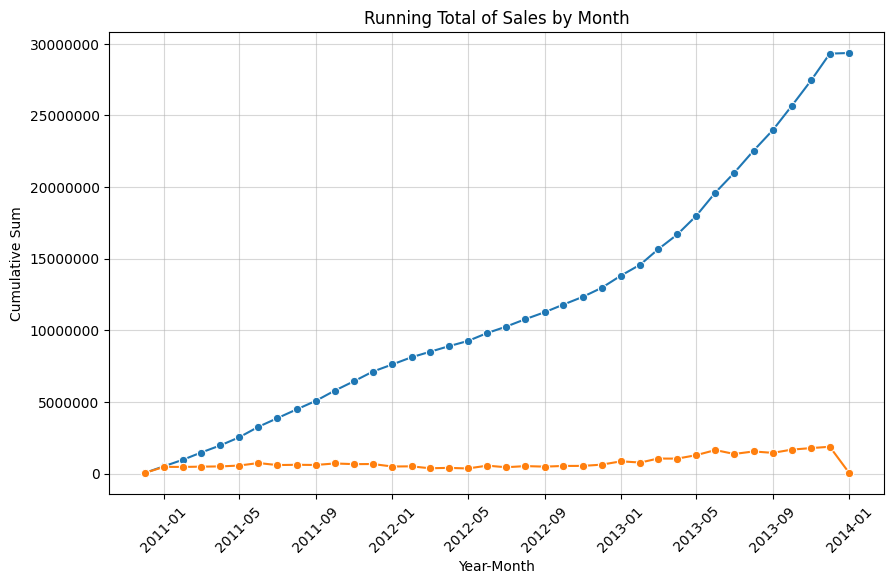

In [19]:
query = '''
WITH cte AS(SELECT
    DATE_TRUNC('month', fact_sales.order_date) sales_month,
    SUM(fact_sales.sales_amount) total_sales
FROM fact_sales
WHERE fact_sales.order_date IS NOT NULL
GROUP BY DATE_TRUNC('month', fact_sales.order_date)
ORDER BY DATE_TRUNC('month', fact_sales.order_date))


SELECT 
    TO_CHAR(Sales_Month, 'YYYY-Mon') Sales_Month,
    Total_Sales,
    SUM(Total_Sales) OVER(ORDER BY Sales_Month ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) Running_Total
FROM cte;'''

df = pd.read_sql_query(query, engine)

df['sales_month'] = pd.to_datetime(df['sales_month'])


plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='sales_month', y='running_total', marker='o')
sns.lineplot(data=df, x='sales_month', y='total_sales', marker='o')
plt.title('Running Total of Sales by Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.xlabel('Year-Month'),
plt.ylabel('Cumulative Sum')
plt.ticklabel_format(style='plain', axis='y')
plt.show()